# Jupyter Notebook
# Lec 18: The Lasso

In this module we are going to test out the lasso method, discussed in class.

In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import time


# ML imports we've used previously
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import make_pipeline


# Fix for deprecation warnings, but we should fix so this isn't here
import warnings 
warnings.filterwarnings('ignore')

# Loading in the data

Ok, here we go, let's play with a baseball data set again. Note this cleanup is all the same as the last lab. 

In [3]:
url ="https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/7c9ee5baa268e98bd5a1cade1809d7fe/Hitters.csv"
hitters_df = pd.read_csv(url)

# Print the dimensions of the original Hitters data (322 rows x 20 columns)
print("Dimensions of original data:", hitters_df.shape)

# Drop any rows the contain missing values, along with the player names
hitters_df = hitters_df.dropna().drop('Player', axis=1)

# Replace any categorical variables with dummy variables
hitters_df = pd.get_dummies(hitters_df, drop_first = True)

hitters_df.head()

Dimensions of original data: (322, 21)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


In [4]:
y = hitters_df.Salary

# Drop the column with the independent variable (Salary)
X = hitters_df.drop(['Salary'], axis = 1).astype('float64')

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        263 non-null    float64
 1   Hits         263 non-null    float64
 2   HmRun        263 non-null    float64
 3   Runs         263 non-null    float64
 4   RBI          263 non-null    float64
 5   Walks        263 non-null    float64
 6   Years        263 non-null    float64
 7   CAtBat       263 non-null    float64
 8   CHits        263 non-null    float64
 9   CHmRun       263 non-null    float64
 10  CRuns        263 non-null    float64
 11  CRBI         263 non-null    float64
 12  CWalks       263 non-null    float64
 13  PutOuts      263 non-null    float64
 14  Assists      263 non-null    float64
 15  Errors       263 non-null    float64
 16  League_N     263 non-null    float64
 17  Division_W   263 non-null    float64
 18  NewLeague_N  263 non-null    float64
dtypes: float64(19

Finally, here's a list of $\alpha$'s to test for our Lasso.

In [5]:
# List of alphas
alphas = 10**np.linspace(4,-2,100)*0.5
alphas

array([5.00000000e+03, 4.34874501e+03, 3.78231664e+03, 3.28966612e+03,
       2.86118383e+03, 2.48851178e+03, 2.16438064e+03, 1.88246790e+03,
       1.63727458e+03, 1.42401793e+03, 1.23853818e+03, 1.07721735e+03,
       9.36908711e+02, 8.14875417e+02, 7.08737081e+02, 6.16423370e+02,
       5.36133611e+02, 4.66301673e+02, 4.05565415e+02, 3.52740116e+02,
       3.06795364e+02, 2.66834962e+02, 2.32079442e+02, 2.01850863e+02,
       1.75559587e+02, 1.52692775e+02, 1.32804389e+02, 1.15506485e+02,
       1.00461650e+02, 8.73764200e+01, 7.59955541e+01, 6.60970574e+01,
       5.74878498e+01, 5.00000000e+01, 4.34874501e+01, 3.78231664e+01,
       3.28966612e+01, 2.86118383e+01, 2.48851178e+01, 2.16438064e+01,
       1.88246790e+01, 1.63727458e+01, 1.42401793e+01, 1.23853818e+01,
       1.07721735e+01, 9.36908711e+00, 8.14875417e+00, 7.08737081e+00,
       6.16423370e+00, 5.36133611e+00, 4.66301673e+00, 4.05565415e+00,
       3.52740116e+00, 3.06795364e+00, 2.66834962e+00, 2.32079442e+00,
      

# Lasso 

Thanks to the wonders of `scikit-learn`, now that we know how to do all this with ridge regression, translation to lasso is super easy. 

- [Lasso Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
- [LassoCV Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html#sklearn.linear_model.LassoCV)
- [User guide](https://scikit-learn.org/stable/modules/linear_model.html#lasso)



In [6]:
from sklearn.linear_model import Lasso, LassoCV

Here's an example computing the lasso regression. 

In [7]:
a = 1 #<------ this is me picking an alpha value

# normalize the input
transformer = StandardScaler().fit(X)
# transformer.set_output(transform = 'pandas') #<---- some older versions of sklearn
                                               #      have issues with this
X_norm = pd.DataFrame(transformer.transform(X), columns = X.columns)

# Fit the regression
lasso = Lasso(alpha = a) 
lasso.fit(X_norm, y)

# Get all the coefficients
print('intercept:', lasso.intercept_)
print('\n')
print(pd.Series(lasso.coef_, index = X_norm.columns))
print('\nTraining MSE:',mean_squared_error(y,lasso.predict(X_norm)))

intercept: 535.9258821292775


AtBat         -281.117268
Hits           303.712775
HmRun           11.130509
Runs           -25.237507
RBI             -0.000000
Walks          120.835970
Years          -35.043287
CAtBat        -161.321987
CHits            0.000000
CHmRun          14.271823
CRuns          375.151758
CRBI           192.215411
CWalks        -190.239127
PutOuts         78.676450
Assists         41.885267
Errors         -18.834451
League_N        23.209008
Division_W     -58.234428
NewLeague_N     -4.941839
dtype: float64

Training MSE: 92609.01554579368


And the version using the `make_pipeline` along with the `StandardScaler` function which gives back the same answer.

In [8]:
a = 1#<------ this is me picking an alpha value


# The make_pipeline command takes care of the normalization and the 
# Lasso regression for you. Note that I am passing in the un-normalized
# matrix X everywhere in here, since the normalization happens internally.
model = make_pipeline(StandardScaler(), Lasso(alpha = a))
model.fit(X, y)
 
# Get all the coefficients. Notice that in order to get 
# them out of the ridge portion, we have to ask the pipeline 
# for the specific bit we want with the model.named_steps['ridge']
# in place of just ridge from above.
print('intercept:', model.named_steps['lasso'].intercept_)
print('\n')
print(pd.Series(model.named_steps['lasso'].coef_, index = X.columns))
print('\nTraining MSE:',mean_squared_error(y,model.predict(X)))

intercept: 535.9258821292775


AtBat         -281.117268
Hits           303.712775
HmRun           11.130509
Runs           -25.237507
RBI             -0.000000
Walks          120.835970
Years          -35.043287
CAtBat        -161.321987
CHits            0.000000
CHmRun          14.271823
CRuns          375.151758
CRBI           192.215411
CWalks        -190.239127
PutOuts         78.676450
Assists         41.885267
Errors         -18.834451
League_N        23.209008
Division_W     -58.234428
NewLeague_N     -4.941839
dtype: float64

Training MSE: 92609.01554579368


&#9989; **<font color=red>Do this:</font>** Mess with the values for $a$ in the code, such as for $a=1, 10, 100, 1000$. What do you notice about the coefficients? 

*Overall pattern you should conclude
As $a$ increases, coefficients shrink toward zero, are more likely to become exactly zero, lasso performs automatic variable selection. Too small $a$, overfitting. Too large $a$, underfitting. This behavior is what makes Lasso especially useful when you suspect that only a subset of predictors truly matter.*

&#9989; **<font color=red>Do this:</font>** Make a graph of the coeffiencts from lasso as $\alpha$ changes 

*Note: we did similar things in the last class but with ridge regression, so I've included the code you can borrow and modify from there. Also note I got a bunch of convergence warnings, but drawing the graphs I could safely ignore them. There's a command you ran in the first box to ignore warnings so they might not show up at all.*

In [11]:
# Your code for computing the coefficients goes here 
# I've included the code from last class that did this for the ridge version
# so you should just need to update it to do lasso instead.


from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

coefs = []

for a in alphas:
    model = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000))
    model.fit(X, y)
    coefs.append(model.named_steps['lasso'].coef_)  # <-- Lasso here

coefs = pd.DataFrame(coefs, columns=X.columns)
coefs.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


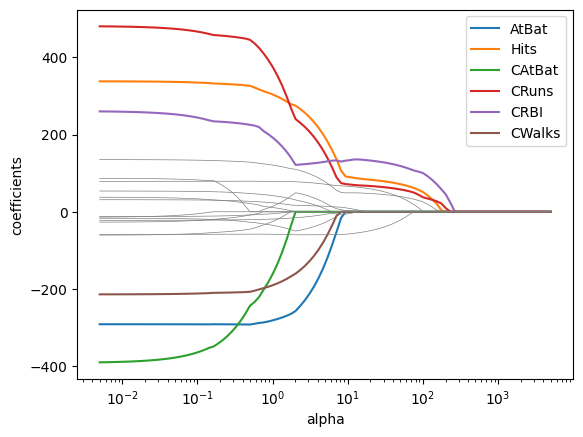

In [12]:
# If that worked above, you'll get a graph in this code. 

for var in coefs.columns:
    # I'm greying out the ones that have magnitude below 200 to easier visualization
    if np.abs(coefs[var][coefs.shape[0]-1])<200:
        plt.plot(alphas, coefs[var], color = 'grey', linewidth = .5)
    else:
        plt.plot(alphas, coefs[var], label = var)

plt.xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('coefficients')

plt.legend()

&#9989; **<font color=red>Do this:</font>** Make a graph the test mean squared error as $\alpha$ changes for a fixed train/test split. 

*Note: again I've included code from last time that you should just have to update.*

In [13]:
# Update this code to get the MSE for lasso instead of Ridge

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

errors = []

for a in alphas:
    model = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000))
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    errors.append(mean_squared_error(y_test, pred))

Min occurs at alpha = 8.15
Min MSE is 115059.67


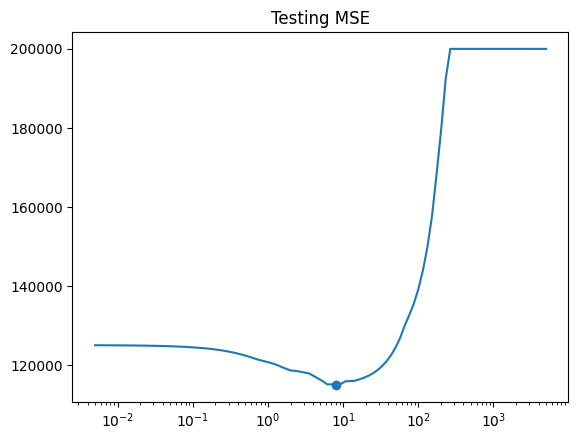

In [14]:
# If that worked, you should see your test error here.
i = np.argmin(errors) # Index of minimum 
print(f'Min occurs at alpha = {alphas[i]:.2f}')
print(f'Min MSE is {errors[i]:.2f}')

plt.title('Testing MSE')
plt.plot(alphas,errors)
plt.scatter(alphas[i],errors[i])
ax=plt.gca()
ax.set_xscale('log')



&#9989; **<font color=red>Do this:</font>** make a plot showing the number of non-zero coefficients as a function of the $\alpha$ choice.

*Hint: I used the `np.count_nonzero` command on the `coefs` data frame we already built*

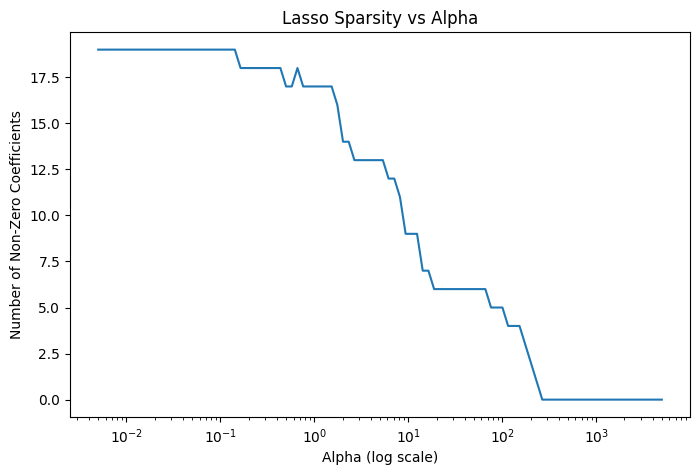

In [16]:
num_nonzero = coefs.apply(np.count_nonzero, axis=1)

num_nonzero.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(alphas, num_nonzero)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Number of Non-Zero Coefficients')
plt.title('Lasso Sparsity vs Alpha')
plt.show()

&#9989; **<font color=red>Q:</font>** Say your goal was to end up with a model with 5 variables used. What choice of $\alpha$ gives us that and what are the variables used?  


In [18]:
num_nonzero = coefs.apply(np.count_nonzero, axis=1)

idx_5 = np.where(num_nonzero == 5)[0][0]

alpha_5 = alphas[idx_5]
alpha_5

vars_5 = coefs.iloc[idx_5]
vars_5[vars_5 != 0]

# Selecting a = alphas[28] results in a Lasso model with exactly five non-zero coefficients.
# The variables retained are Hits, Walks, CRuns, CRBI, and PutOuts, while all remaining predictors are eliminated.
# This demonstrates Lasso’s ability to perform automatic variable selection
# by retaining only the most informative predictors of salary.

Hits        50.976632
Walks       25.478013
CRuns       37.424240
CRBI       100.218679
PutOuts      0.630336
Name: 28, dtype: float64

## Lasso with Cross Validation

&#9989; **<font color=red>Do this:</font>** Now try what we did with `LassoCV`.  What choice of $\alpha$ does it recommend? 

*I would actually recommend either not passing in any $\alpha$ list or passing explicitly `alphas = None`. `RidgeCV` can't do this, but `LassoCV` will automatically try to find good choices of $\alpha$ for you.*

In [19]:
# Here's the ridge code from last time that you should update

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

transformer = StandardScaler().fit(X_train)
X_train_norm = pd.DataFrame(
    transformer.transform(X_train),
    columns=X_train.columns)
X_test_norm = transformer.transform(X_test)

lassocv = LassoCV(
    alphas=None,
    cv=5,
    max_iter=10000,
    random_state=1)

lassocv.fit(X_train_norm, y_train)

print("Alpha chosen by LassoCV:", lassocv.alpha_)

Alpha chosen by LassoCV: 1.0800619536094402


In [20]:
# Your code here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)
transformer = StandardScaler().fit(X_train)
X_train_norm = pd.DataFrame(
    transformer.transform(X_train),
    columns=X_train.columns
)
X_test_norm = transformer.transform(X_test)

lassocv = LassoCV(
    alphas=None,
    cv=5,
    max_iter=10000,
    random_state=1)
lassocv.fit(X_train_norm, y_train)

print("Alpha chosen by LassoCV:", lassocv.alpha_)

Alpha chosen by LassoCV: 1.0800619536094402


Now let's take a look at some of the coefficients. 

In [21]:
# Some of the coefficients are now reduced to exactly zero.
pd.Series(lassocv.coef_, index=X.columns)

AtBat         -328.601267
Hits           351.501357
HmRun          -28.435135
Runs           -48.625331
RBI             56.256350
Walks          124.840026
Years           -0.000000
CAtBat        -368.328399
CHits          365.286546
CHmRun         143.047744
CRuns          128.855535
CRBI            70.376722
CWalks        -143.423781
PutOuts         93.738170
Assists          9.972723
Errors           0.274326
League_N         8.803090
Division_W     -60.734020
NewLeague_N      9.219834
dtype: float64

&#9989; **<font color=red>Q:</font>** We've been repeating over and over that lasso gives us coefficients that are actually 0.  At least in my code, I'm not seeing many that are 0. What happened? Can I change something to get more 0 entries? 



In [22]:
###Your answer here###You might also want some code in here to try to figure it out

# Even though Lasso can produce exact zeros, it is not guaranteed to do so unless the regularization strength is large enough.
# LassoCV chose a small a. LassoCV selects the a that minimizes cross-validated MSE
# That optimal a prioritizes prediction accuracy, not sparsity
# A smaller a, weaker penalty, fewer coefficients forced to zero
# Floating-point math hides “near-zero” coefficients
# Some coefficients (like Years = -0.000000) are
# Extremely close to zero
# But not exactly zero due to numerical precision
# Lasso is solving an optimization problem numerically, so tiny values may survive.
# Get more exact zeros by using a larger a value:
lasso_strong = Lasso(alpha=lassocv.alpha_ * 5, max_iter=10000)
lasso_strong.fit(X_train_norm, y_train)

pd.Series(lasso_strong.coef_, index=X.columns)

AtBat         -193.445822
Hits           244.279193
HmRun           -9.310476
Runs            -0.000000
RBI             14.759412
Walks           80.045957
Years           -0.170976
CAtBat          -0.000000
CHits           46.832695
CHmRun          78.676020
CRuns            0.000000
CRBI           132.632076
CWalks         -62.091158
PutOuts         93.055829
Assists         -0.000000
Errors           0.000000
League_N         0.000000
Division_W     -58.004127
NewLeague_N     15.209135
dtype: float64



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.